ı İndirilen dosyalar: ['WHR2023.csv']
CSV dosyaları: ['WHR2023.csv']
Kullanılan dosya: WHR2023.csv
Ham sütunlar: ['Country name', 'Ladder score', 'Standard error of ladder score', 'upperwhisker', 'lowerwhisker', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Ladder score in Dystopia', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']

 136 ñlke | Özellikler: ['GDP_PerCapita', 'SocialSupport', 'HealthyLife', 'Freedom', 'Generosity', 'Corruption']

ı En mutlu 10:
    Country  HappinessScore
    Finland           7.804
    Denmark           7.586
    Iceland           7.530
     Israel           7.473
Netherlands           7.403
     Sweden           7.395
     Norway           7.315
Switzerland 

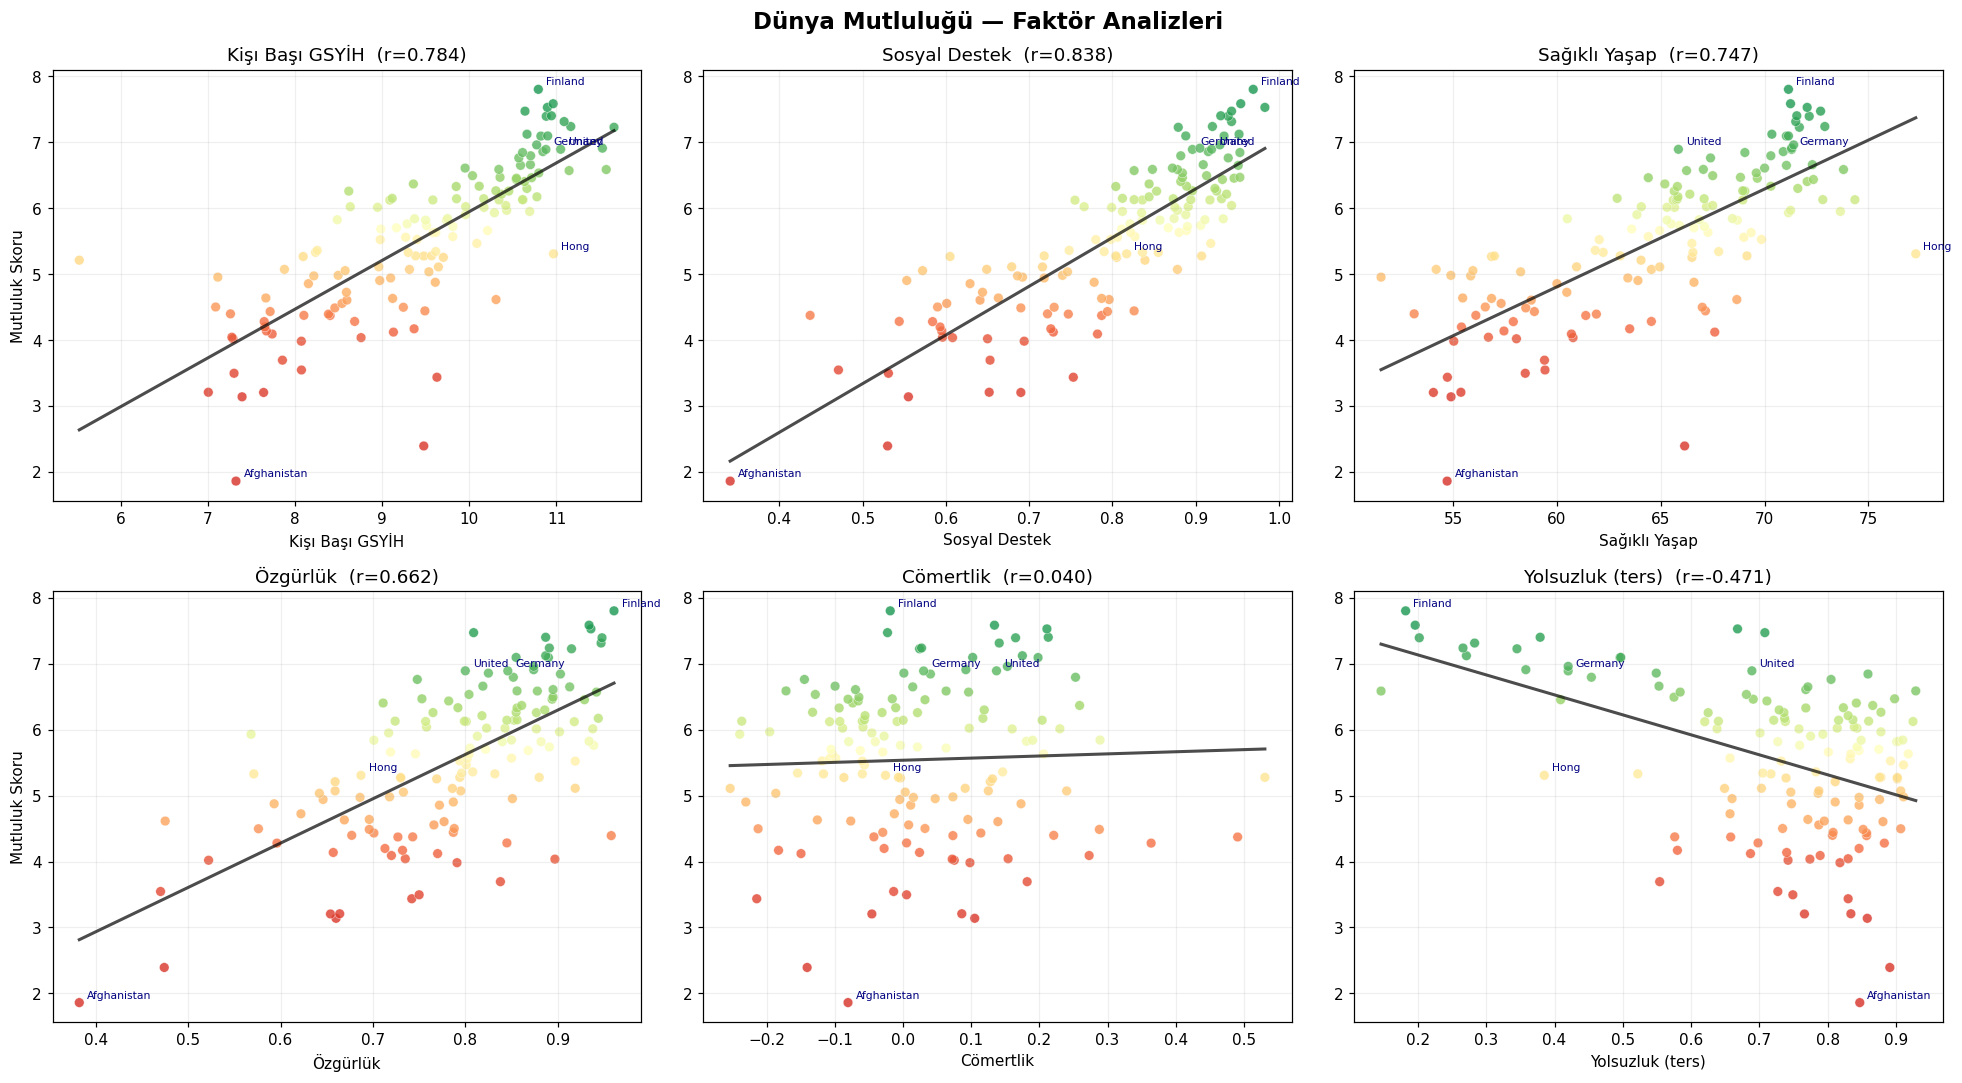

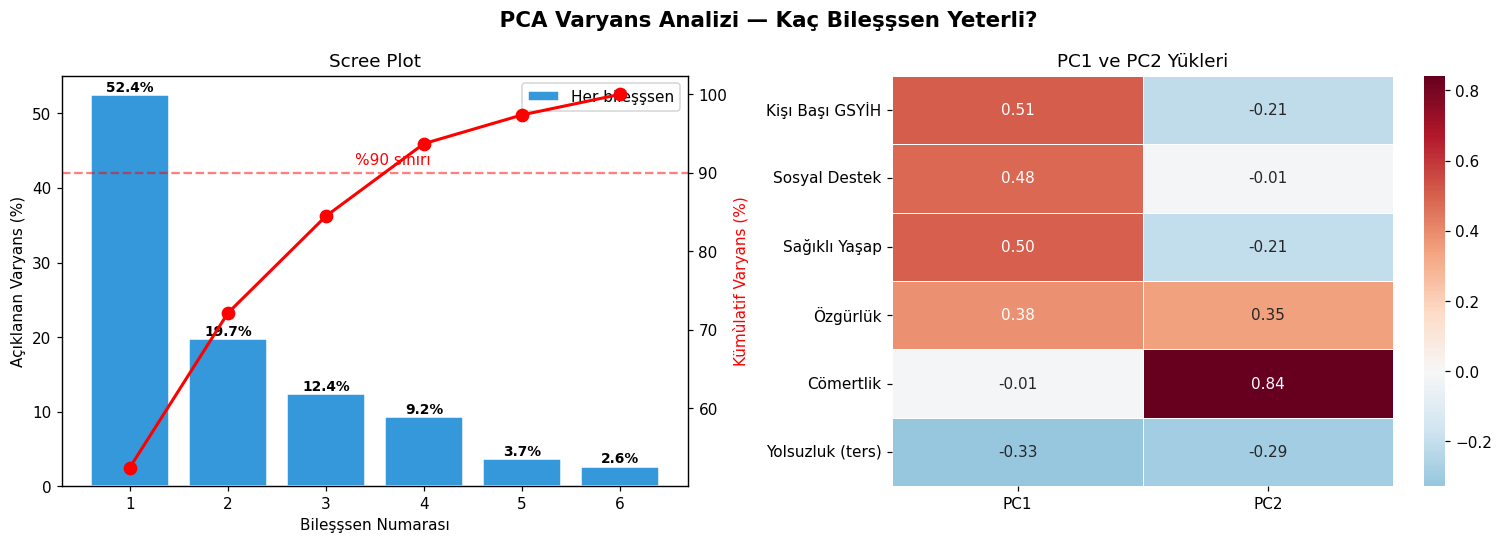


ı Varyans Özeti:
  PC1: 52.4%  (kümùlatif: 52.4%)
  PC2: 19.7%  (kümùlatif: 72.1%)
  PC3: 12.4%  (kümùlatif: 84.5%)
  PC4: 9.2%  (kümùlatif: 93.7%)
  PC5: 3.7%  (kümùlatif: 97.4%)
  PC6: 2.6%  (kümùlatif: 100.0%)


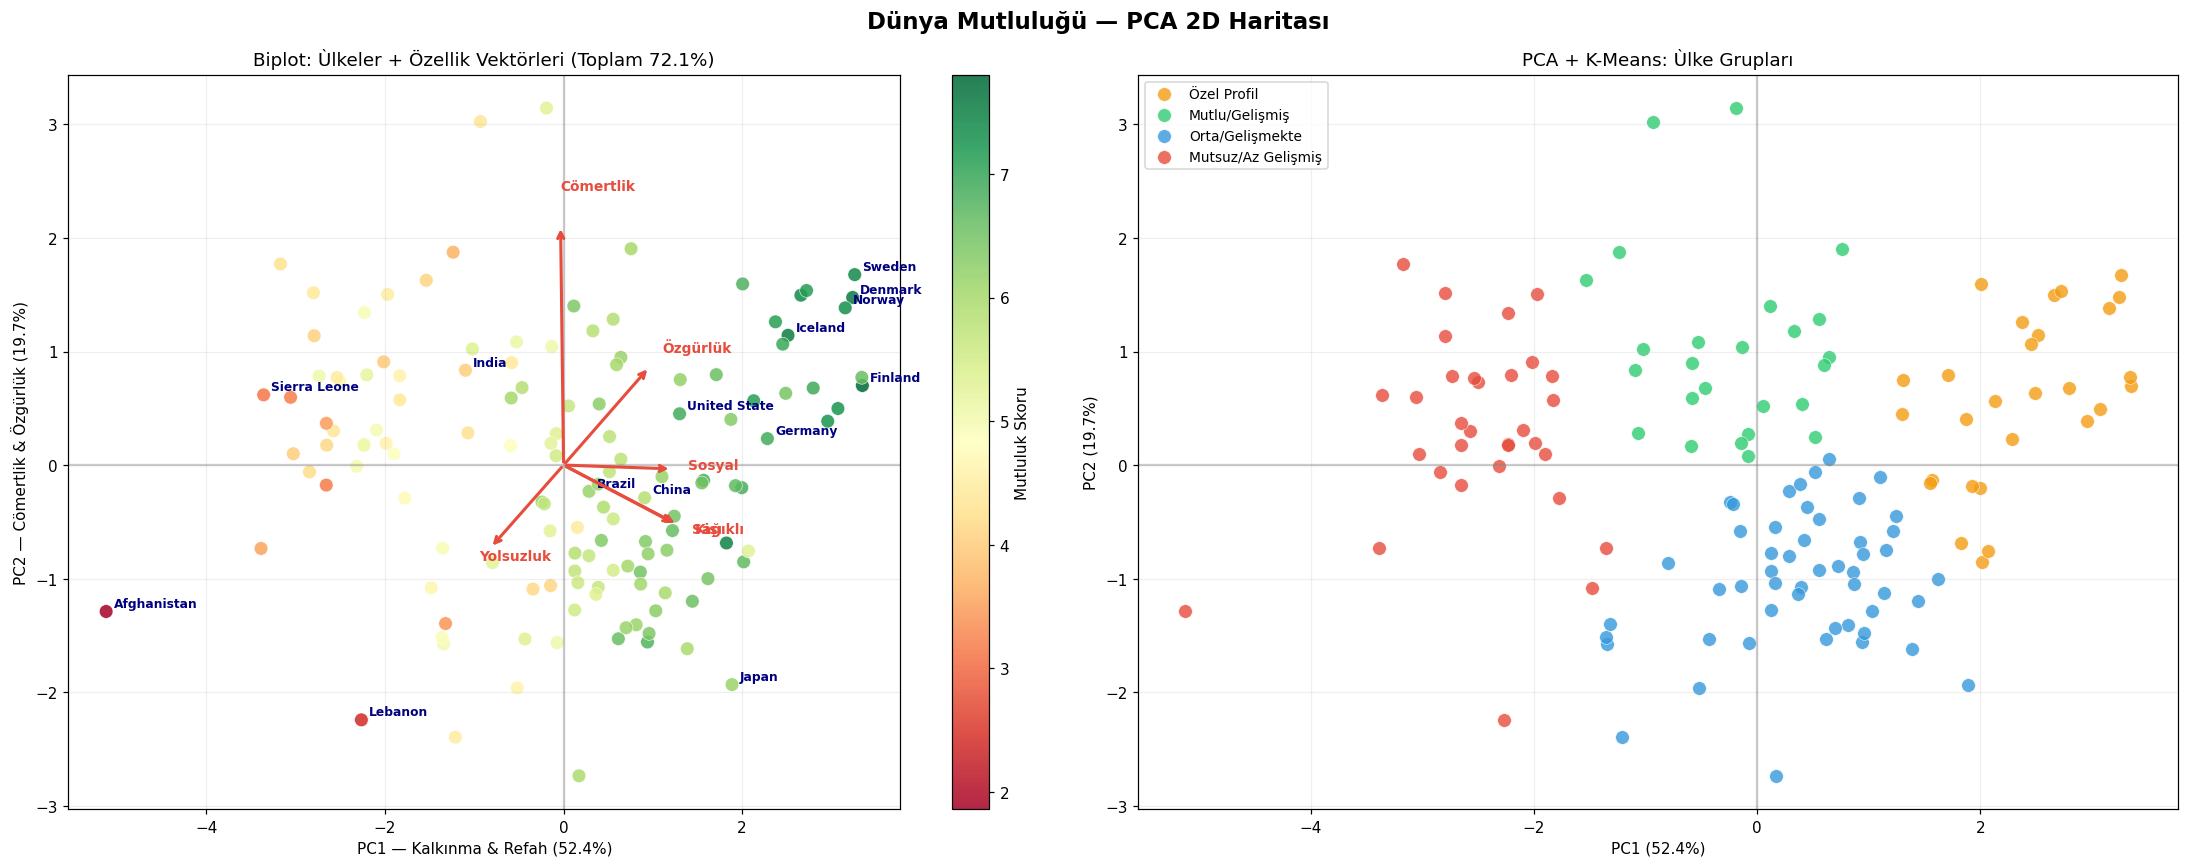


ı PC1 (52.4%) = Kalkınma ekseni | PC2 (19.7%) = Özgürlük/Cömertlik ekseni


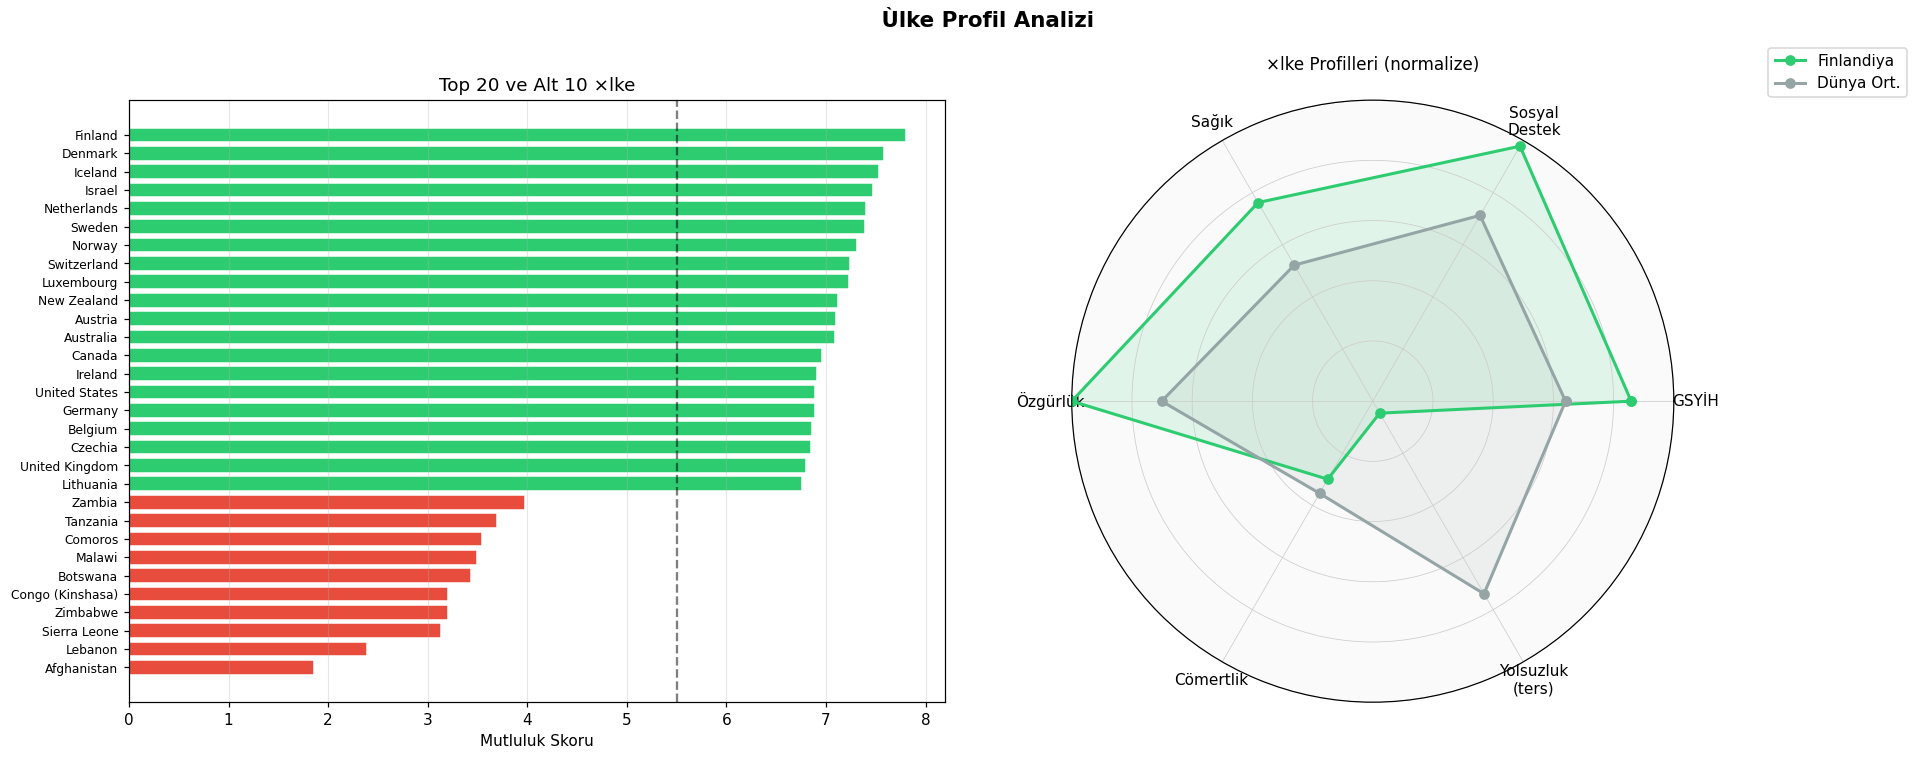



✈ Finland  →  136 ùlke içinde 1. sıra | Skor: 7.804
   PCA: PC1=3.35, PC2=0.70
   Kişı Başı GSYİH              10.792  (↑ yüksek | ort: 9.455)
   Sosyal Destek                0.969  (↑ yüksek | ort: 0.799)
   Sağıklı Yaşap                71.150  (↑ yüksek | ort: 64.968)
   Özgürlük                     0.961  (↑ yüksek | ort: 0.788)
   Cömertlik                    -0.019  (↓ düşük | ort: 0.024)
   Yolsuzluk (ters)             0.182  (↓ düşük | ort: 0.725)
 'Turkey' bulunamadı.

✈ United States  →  136 ùlke içinde 15. sıra | Skor: 6.894
   PCA: PC1=1.30, PC2=0.45
   Kişı Başı GSYİH              11.048  (↑ yüksek | ort: 9.455)
   Sosyal Destek                0.919  (↑ yüksek | ort: 0.799)
   Sağıklı Yaşap                65.850  (↑ yüksek | ort: 64.968)
   Özgürlük                     0.800  (↑ yüksek | ort: 0.788)
   Cömertlik                    0.137  (↑ yüksek | ort: 0.024)
   Yolsuzluk (ters)             0.689  (↓ düşük | ort: 0.725)

ı ulke_profili('Germany') ile istediğın ùlkeyi an

In [ ]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

path = kagglehub.dataset_download("ajaypalsinghlo/world-happiness-report-2023")
print("ı İndirilen dosyalar:", os.listdir(path))

csv_files = sorted([f for f in os.listdir(path) if f.endswith('.csv')])
print("CSV dosyaları:", csv_files)
target = [f for f in csv_files if '2023' in f]
csv_file = target[0] if target else csv_files[-1]
print(f"Kullanılan dosya: {csv_file}")

df_raw = pd.read_csv(os.path.join(path, csv_file))
print("Ham sütunlar:", list(df_raw.columns))

target_col_map = {
    'country name': 'Country',
    'ladder score': 'HappinessScore',
    'logged gdp per capita': 'GDP_PerCapita',
    'social support': 'SocialSupport',
    'healthy life expectancy': 'HealthyLife',
    'freedom to make life choices': 'Freedom',
    'generosity': 'Generosity',
    'perceptions of corruption': 'Corruption'
}

col_map = {}
for c in df_raw.columns:
    cl = c.lower()
    if cl in target_col_map:
        col_map[c] = target_col_map[cl]
df_raw.rename(columns=col_map, inplace=True)

features = [f for f in ['GDP_PerCapita','SocialSupport','HealthyLife',
                         'Freedom','Generosity','Corruption'] if f in df_raw.columns]
if 'HappinessScore' not in df_raw.columns:
    num_cols = df_raw.select_dtypes(include='number').columns.tolist()
    df_raw['HappinessScore'] = df_raw[num_cols[0]] if num_cols else np.nan

df = df_raw[['Country','HappinessScore'] + features].dropna().reset_index(drop=True)

feature_names_tr = {
    'GDP_PerCapita': 'Kişı Başı GSYİH',
    'SocialSupport': 'Sosyal Destek',
    'HealthyLife':   'Sağıklı Yaşap',
    'Freedom':       'Özgürlük',
    'Generosity':    'Cömertlik',
    'Corruption':    'Yolsuzluk (ters)'
}

print(f"\n {len(df)} ñlke | Özellikler: {features}")
print(f"\nı En mutlu 10:\n{df.nlargest(10,'HappinessScore')[['Country','HappinessScore']].to_string(index=False)}")
print(f"\nı En mutsuz 10:\n{df.nsmallest(10,'HappinessScore')[['Country','HappinessScore']].to_string(index=False)}")

turkey_mask = df.Country.str.contains('Turk', case=False, na=False)
if turkey_mask.any():
    t_row  = df[turkey_mask].iloc[0]
    t_rank = int(df['HappinessScore'].rank(ascending=False).loc[t_row.name])
    print(f"\nı Türkiye: {t_row.HappinessScore:.3f} — {len(df)} ñlke içinde {t_rank}. sırada")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(' Dünya Mutluluğü — Faktör Analizleri', fontsize=15, fontweight='bold')

sorted_df   = df.sort_values('HappinessScore')
colors_grad = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(sorted_df)))

for ax, feat in zip(axes.flat, features):
    name_tr = feature_names_tr.get(feat, feat)
    x, yc   = sorted_df[feat], sorted_df['HappinessScore']
    ax.scatter(x, yc, c=colors_grad, s=40, alpha=0.8, edgecolors='white', linewidth=0.3)
    z = np.polyfit(x, yc, 1)
    ax.plot(sorted(x), np.poly1d(z)(sorted(x)), 'k-', linewidth=2, alpha=0.7)
    for country in ['Finland','Afghanistan','Turkey','Türkiye','United States','Germany','China']:
        mask = sorted_df.Country.str.contains(country, case=False, na=False)
        if mask.any():
            row = sorted_df[mask].iloc[0]
            ax.annotate(row.Country.split()[0], (row[feat], row['HappinessScore']),
                        fontsize=7, color='navy', xytext=(5,3), textcoords='offset points')
    r_val = x.corr(yc)
    ax.set_xlabel(name_tr, fontsize=10)
    ax.set_ylabel('Mutluluk Skoru' if ax in [axes[0,0], axes[1,0]] else '')
    ax.set_title(f'{name_tr}  (r={r_val:.3f})')
    ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

Z      = df[features].values
scaler = StandardScaler()
X_s    = scaler.fit_transform(Z) # Changed X to Z

pca_full = PCA(random_state=42)
pca_full.fit(X_s)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_feat = len(features)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' PCA Varyans Analizi — Kaç Bileşşsen Yeterli?', fontsize=14, fontweight='bold')

ax1.bar(range(1, n_feat+1), pca_full.explained_variance_ratio_*100,
        color='#3498DB', edgecolor='white', label='Her bileşşsen')
ax1t = ax1.twinx()
ax1t.plot(range(1, n_feat+1), cumvar, 'ro-', linewidth=2, markersize=8, label='Kümùlatif')
ax1t.axhline(90, color='red', linestyle='--', alpha=0.5)
ax1t.text(n_feat*0.55, 91, '%90 sınırı', color='red', fontsize=10)
ax1.set_xlabel('Bileşşsen Numarası'); ax1.set_ylabel('Açıklanan Varyans (%)')
ax1t.set_ylabel('Kümùlatif Varyans (%)', color='red')
ax1.set_title('Scree Plot'); ax1.legend(loc='upper right')
for i, v in enumerate(pca_full.explained_variance_ratio_*100):
    ax1.text(i+1, v+0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

loadings = pd.DataFrame(pca_full.components_[:2].T,
                         index=[feature_names_tr.get(f,f) for f in features],
                         columns=['PC1','PC2'])
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax2, linewidths=0.5)
ax2.set_title('PC1 ve PC2 Yükleri'); ax2.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

print("\nı Varyans Özeti:")
for i, (v, cv) in enumerate(zip(pca_full.explained_variance_ratio_*100, cumvar)):
    print(f"  PC{i+1}: {v:.1f}%  (kümùlatif: {cv:.1f}%)")

pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_s)
var1   = pca_2d.explained_variance_ratio_[0]*100
var2   = pca_2d.explained_variance_ratio_[1]*100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(' Dünya Mutluluğü — PCA 2D Haritası', fontsize=15, fontweight='bold')

sc = axes[0].scatter(X_2d[:,0], X_2d[:,1], c=df['HappinessScore'],
                     cmap='RdYlGn', s=80, alpha=0.85, edgecolors='white', linewidth=0.4)
plt.colorbar(sc, ax=axes[0], label='Mutluluk Skoru')

highlight = ['Finland','Denmark','Iceland','Sweden','Norway',
             'Afghanistan','Lebanon','Sierra Leone',
             'Turkey','Türkiye','Germany','United States','China','Brazil','India','Japan']
for i, row in df.iterrows():
    if any(row.Country.startswith(h) for h in highlight):
        axes[0].annotate(row.Country[:12], (X_2d[i,0], X_2d[i,1]),
                         fontsize=8, fontweight='bold',
                         xytext=(5,3), textcoords='offset points', color='navy')

scale = 2.5
for j, feat in enumerate(features):
    axes[0].annotate('', xy=(pca_2d.components_[0,j]*scale, pca_2d.components_[1,j]*scale),
                     xytext=(0,0), arrowprops={'arrowstyle':'->','color':'#E74C3C','lw':2})
    axes[0].text(pca_2d.components_[0,j]*scale*1.15, pca_2d.components_[1,j]*scale*1.15,
                 feature_names_tr.get(feat,feat).split()[0], color='#E74C3C', fontsize=9, fontweight='bold')

axes[0].set_xlabel(f'PC1 — Kalkınma & Refah ({var1:.1f}%)')
axes[0].set_ylabel(f'PC2 — Cömertlik & Özgürlük ({var2:.1f}%)')
axes[0].set_title(f'Biplot: Ùlkeler + Özellik Vektörleri (Toplam {var1+var2:.1f}%)')
axes[0].grid(True, alpha=0.2)
axes[0].axhline(0, color='gray', alpha=0.4); axes[0].axvline(0, color='gray', alpha=0.4)

km       = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = km.fit_predict(X_2d)
c_colors = ['#E74C3C','#2ECC71','#3498DB','#F39C12']
c_labels = ['Mutsuz/Az Gelişmiş','Mutlu/Gelişmiş','Orta/Gelişmekte','Özel Profil']

df_tmp  = pd.DataFrame({'happy':df['HappinessScore'].values,'cl':clusters})
order   = df_tmp.groupby('cl')['happy'].mean().sort_values().index.tolist()
recolor = {old: c_colors[new] for new, old in enumerate(order)}
relabel = {old: c_labels[new] for new, old in enumerate(order)}

for c in range(4):
    mask = clusters == c
    axes[1].scatter(X_2d[mask,0], X_2d[mask,1],
                    c=recolor[c], s=80, alpha=0.8, label=relabel[c],
                    edgecolors='white', linewidth=0.4)
axes[1].set_xlabel(f'PC1 ({var1:.1f}%)'); axes[1].set_ylabel(f'PC2 ({var2:.1f}%)')
axes[1].set_title('PCA + K-Means: Ùlke Grupları')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].grid(True, alpha=0.2)
axes[1].axhline(0, color='gray', alpha=0.4); axes[1].axvline(0, color='gray', alpha=0.4)
plt.tight_layout(); plt.show()
print(f"\nı PC1 ({var1:.1f}%) = Kalkınma ekseni | PC2 ({var2:.1f}%) = Özgürlük/Cömertlik ekseni")

fig = plt.figure(figsize=(18, 7))
fig.suptitle(' Ùlke Profil Analizi', fontsize=14, fontweight='bold')

# Top20 + Bottom10 yatay bar
top20 = df.nlargest(20,'HappinessScore')
bot10 = df.nsmallest(10,'HappinessScore')
combo = pd.concat([top20,bot10]).drop_duplicates().sort_values('HappinessScore')
b_col = ['#2ECC71' if v>=6 else ('#F39C12' if v>=5 else '#E74C3C') for v in combo['HappinessScore']]

ax_bar = fig.add_subplot(121)
ax_bar.barh(range(len(combo)), combo['HappinessScore'], color=b_col, edgecolor='white')
ax_bar.set_yticks(range(len(combo)))
ax_bar.set_yticklabels(combo['Country'], fontsize=8)
ax_bar.set_xlabel('Mutluluk Skoru'); ax_bar.set_title('Top 20 ve Alt 10 ×lke')
ax_bar.axvline(5.5, color='black', linestyle='--', alpha=0.5)
ax_bar.grid(True, alpha=0.3, axis='x')
for i, (_, row) in enumerate(combo.iterrows()):
    if 'Turk' in str(row.Country):
        ax_bar.barh(i, row.HappinessScore, color='#CC0000', edgecolor='white')

ax_radar  = fig.add_subplot(122, projection='polar')
ax_radar.set_facecolor('#FAFAFA')
feat_short = ['GSYİH','Sosyal\nDestek','Sağık','Özgürlük','Cömertlik','Yolsuzluk\n(ters)']
angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]
min_v = df[features].min().values
max_v = df[features].max().values

for c_name, color, label in [('Finland','#2ECC71','Finlandiya'),
                               ('Turkey', '#E74C3C','Türkiye'),
                               ('__world__','#95A5A6','Dünya Ort.')]:
    if c_name == '__world__':
        raw = df[features].mean().values
    else:
        mask = df.Country.str.contains(c_name, case=False, na=False)
        if not mask.any():
            mask = df.Country.str.contains('Türk', case=False, na=False)
        if not mask.any():
            continue
        raw = df[mask][features].values[0]
    norm = (raw - min_v) / (max_v - min_v + 1e-8)
    vals = norm.tolist() + [norm[0]]
    ax_radar.plot(angles, vals, 'o-', color=color, linewidth=2, label=label)
    ax_radar.fill(angles, vals, color=color, alpha=0.12)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(feat_short, fontsize=10)
ax_radar.set_ylim(0,1); ax_radar.set_yticklabels([])
ax_radar.grid(color='#CCCCCC', linewidth=0.5)
ax_radar.set_title('×lke Profilleri (normalize)', fontsize=11, pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.4,1.1), fontsize=10)
plt.tight_layout(); plt.show()

def ulke_profili(ulke_adi):
    """İstenen ùlkenin PCA koordinatı, sıralaması ve gösterge profilini verir."""
    mask = df.Country.str.contains(ulke_adi, case=False, na=False)
    if not mask.any():
        print(f" '{ulke_adi}' bulunamadı."); return
    row  = df[mask].iloc[0]
    idx  = df.index.get_loc(df[mask].index[0])
    rank = int(df['HappinessScore'].rank(ascending=False).loc[row.name])
    print(f"\n {row.Country}  →  {len(df)} ùlke içinde {rank}. sıra | Skor: {row.HappinessScore:.3f}")
    print(f"   PCA: PC1={X_2d[idx,0]:.2f}, PC2={X_2d[idx,1]:.2f}")
    for feat in features:
        val = row[feat]; avg = df[feat].mean()
        rel = '↑ yüksek' if val > avg else '↓ düşük'
        print(f"   {feature_names_tr.get(feat,feat):<28} {val:.3f}  ({rel} | ort: {avg:.3f})")

print("\n" + "="*60)
ulke_profili('Finland')
ulke_profili('Turkey')
ulke_profili('United States')
print("\nı ulke_profili('Germany') ile istediğın ùlkeyi analiz et!")
print("\n Tamamlandı!")